In [323]:
from BLEanalysis.signals import Signals
from BLEanalysis.angleinference import AnglesUsePeaks, AnglesUseRejectionSampling, AnglesUsePatternMeans, normalise_logs_to_ps
from BLEanalysis.pathinference import Path_ProbabilityDensitiesToBee, Path_VectorsToBee
from BLEanalysis.kernels import ExponentiatedQuadraticKernel,EQIntegralKernel
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from jax.random import normal
import jax
from jax.random import multivariate_normal as mvn
from BLEanalysis.angleinference import AnglesUsePatternMeans, normalise_logs_to_ps
from scipy.stats import circmean
import pickle
#rejectionSampling = AnglesUseRejectionSampling(rejectionTableStep = 50)

Load the file we want to infer a path from,

In [324]:
pathIndex = 1
nSamps = 15 # Max number of samples to use per burst for path reconstruction
             # (2 second bursts, how many samples within that burst)
paths = [["../bluetooth_experiments/March 26 2025 Field Trial/complexpath7/complexpath7.log", "../bluetooth_experiments/March 26 2025 Field Trial/complexpath7/2025-03-26_12_05_30_my_iOS_device.csv", 8,26],
         ["../bluetooth_experiments/March 26 2025 Field Trial/complexpath8/complexpath8.log","../bluetooth_experiments/March 26 2025 Field Trial/complexpath8/2025-03-26_12_09_13_my_iOS_device.csv",5,24],
         ["../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/complexpath9.log","../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/2025-03-26_12_13_54_my_iOS_device.csv" ,5,28]]






In [325]:
testdata = Signals(paths[pathIndex][0],['c','a','b','e'],filetype='log',angleOffset=0)
GPSfilepath = paths[pathIndex][1]

# For evaluating the GPS path pointwise against the inferred path, we want to infer a path across the times that we've tracked with GPS
startingTime = paths[pathIndex][2]
endingTime = paths[pathIndex][3]

Standardising angles and times (shifting by 0.00 degrees)


Define hyperparameters (keep the same across all tests):

In [326]:
nInd = 60 # Number of inducing points
noise = 1 # Noise scale
timeScale = 10000 # Scale time series down by this factor when preparing observations
margin = 0.3 # Percentage of time that inducing points will be selected between outside the actual time series of the data

burstLength = 2000 # in ms
samplingMethod = "linspaceIdxs" # random, linspaceTimes, linspaceIdxs

# k(ls,sf)
#k = ExponentiatedQuadraticKernel(3,13)
#k = EQIntegralKernel(2,5)
k = EQIntegralKernel(0.5,0.5)

Define the transmitter IDs, locations and times,

Transmitter       Number of records
        a                 6440
        b                 8629
        c                 9514
        e                 5895


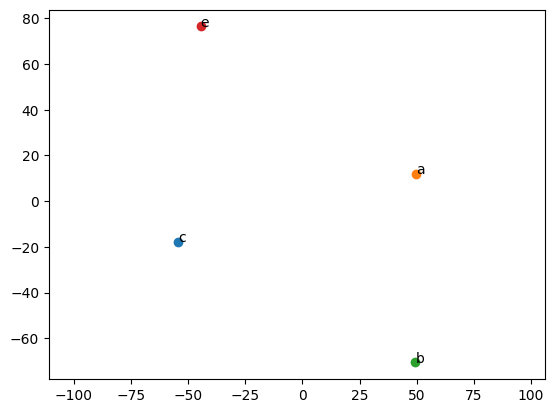

In [327]:
testdata.configureTransmitter('c',0,np.deg2rad(10),transmitterLat = 53.368359, transmitterLon = -1.450168)
testdata.configureTransmitter('a',-(167340+194210),0,transmitterLat = 53.368606, transmitterLon = -1.448596)
testdata.configureTransmitter('b',-(167340+194210+121110),-np.deg2rad(15),transmitterLat = 53.367865, transmitterLon = -1.448626)
testdata.configureTransmitter('e',-167340,0,transmitterLat = 53.369204, transmitterLon = -1.449990)
# Normalise the transmitter locations around zero, in preparation for the observations
testdata.noramliseTransmitterLocs()
testdata.summarise(showNormalised = True)

# Using peak signal strength heuristic

Prepare observations,

In [335]:
obs = []
obstimes = []

# Get packet bursts from data
burst, time = testdata.parseBursts(burstInterval=0)
angles = AnglesUsePeaks(windowLength=3)

# For each burst
for b in range(len(burst)):
    # Infer an angle
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    prediction = angles.infer(burst[b]['rssis'], burst[b]['angles'])
    # If a peak was found
    if not (np.isnan(prediction)):
        # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
        obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
        # Add time of observation
        obstimes.append(time[b])

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


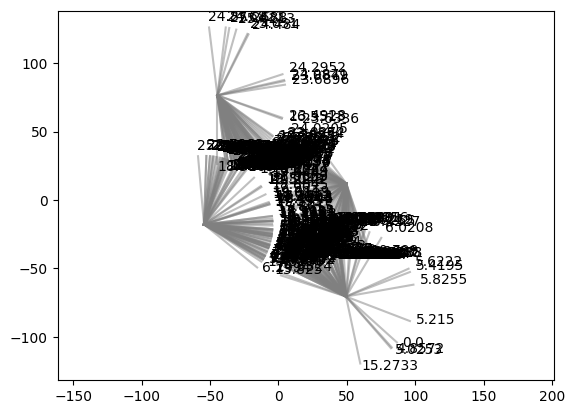

In [336]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*55, observation[1]+observation[3]*55, time)

Perform inference,

In [337]:
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * margin, jitter = 0.1)
path.run(200,learning_rate=2, just_optimise_means = False)

Optimising mean...
iteration    0:  262946.4
iteration   50:   73474.0
iteration  100:   71003.2
iteration  150:   70938.4
Optimising mean and covariance...
iteration    0:   81074.3
iteration   50:   63619.0
iteration  100:   43382.9
iteration  150:   34901.8


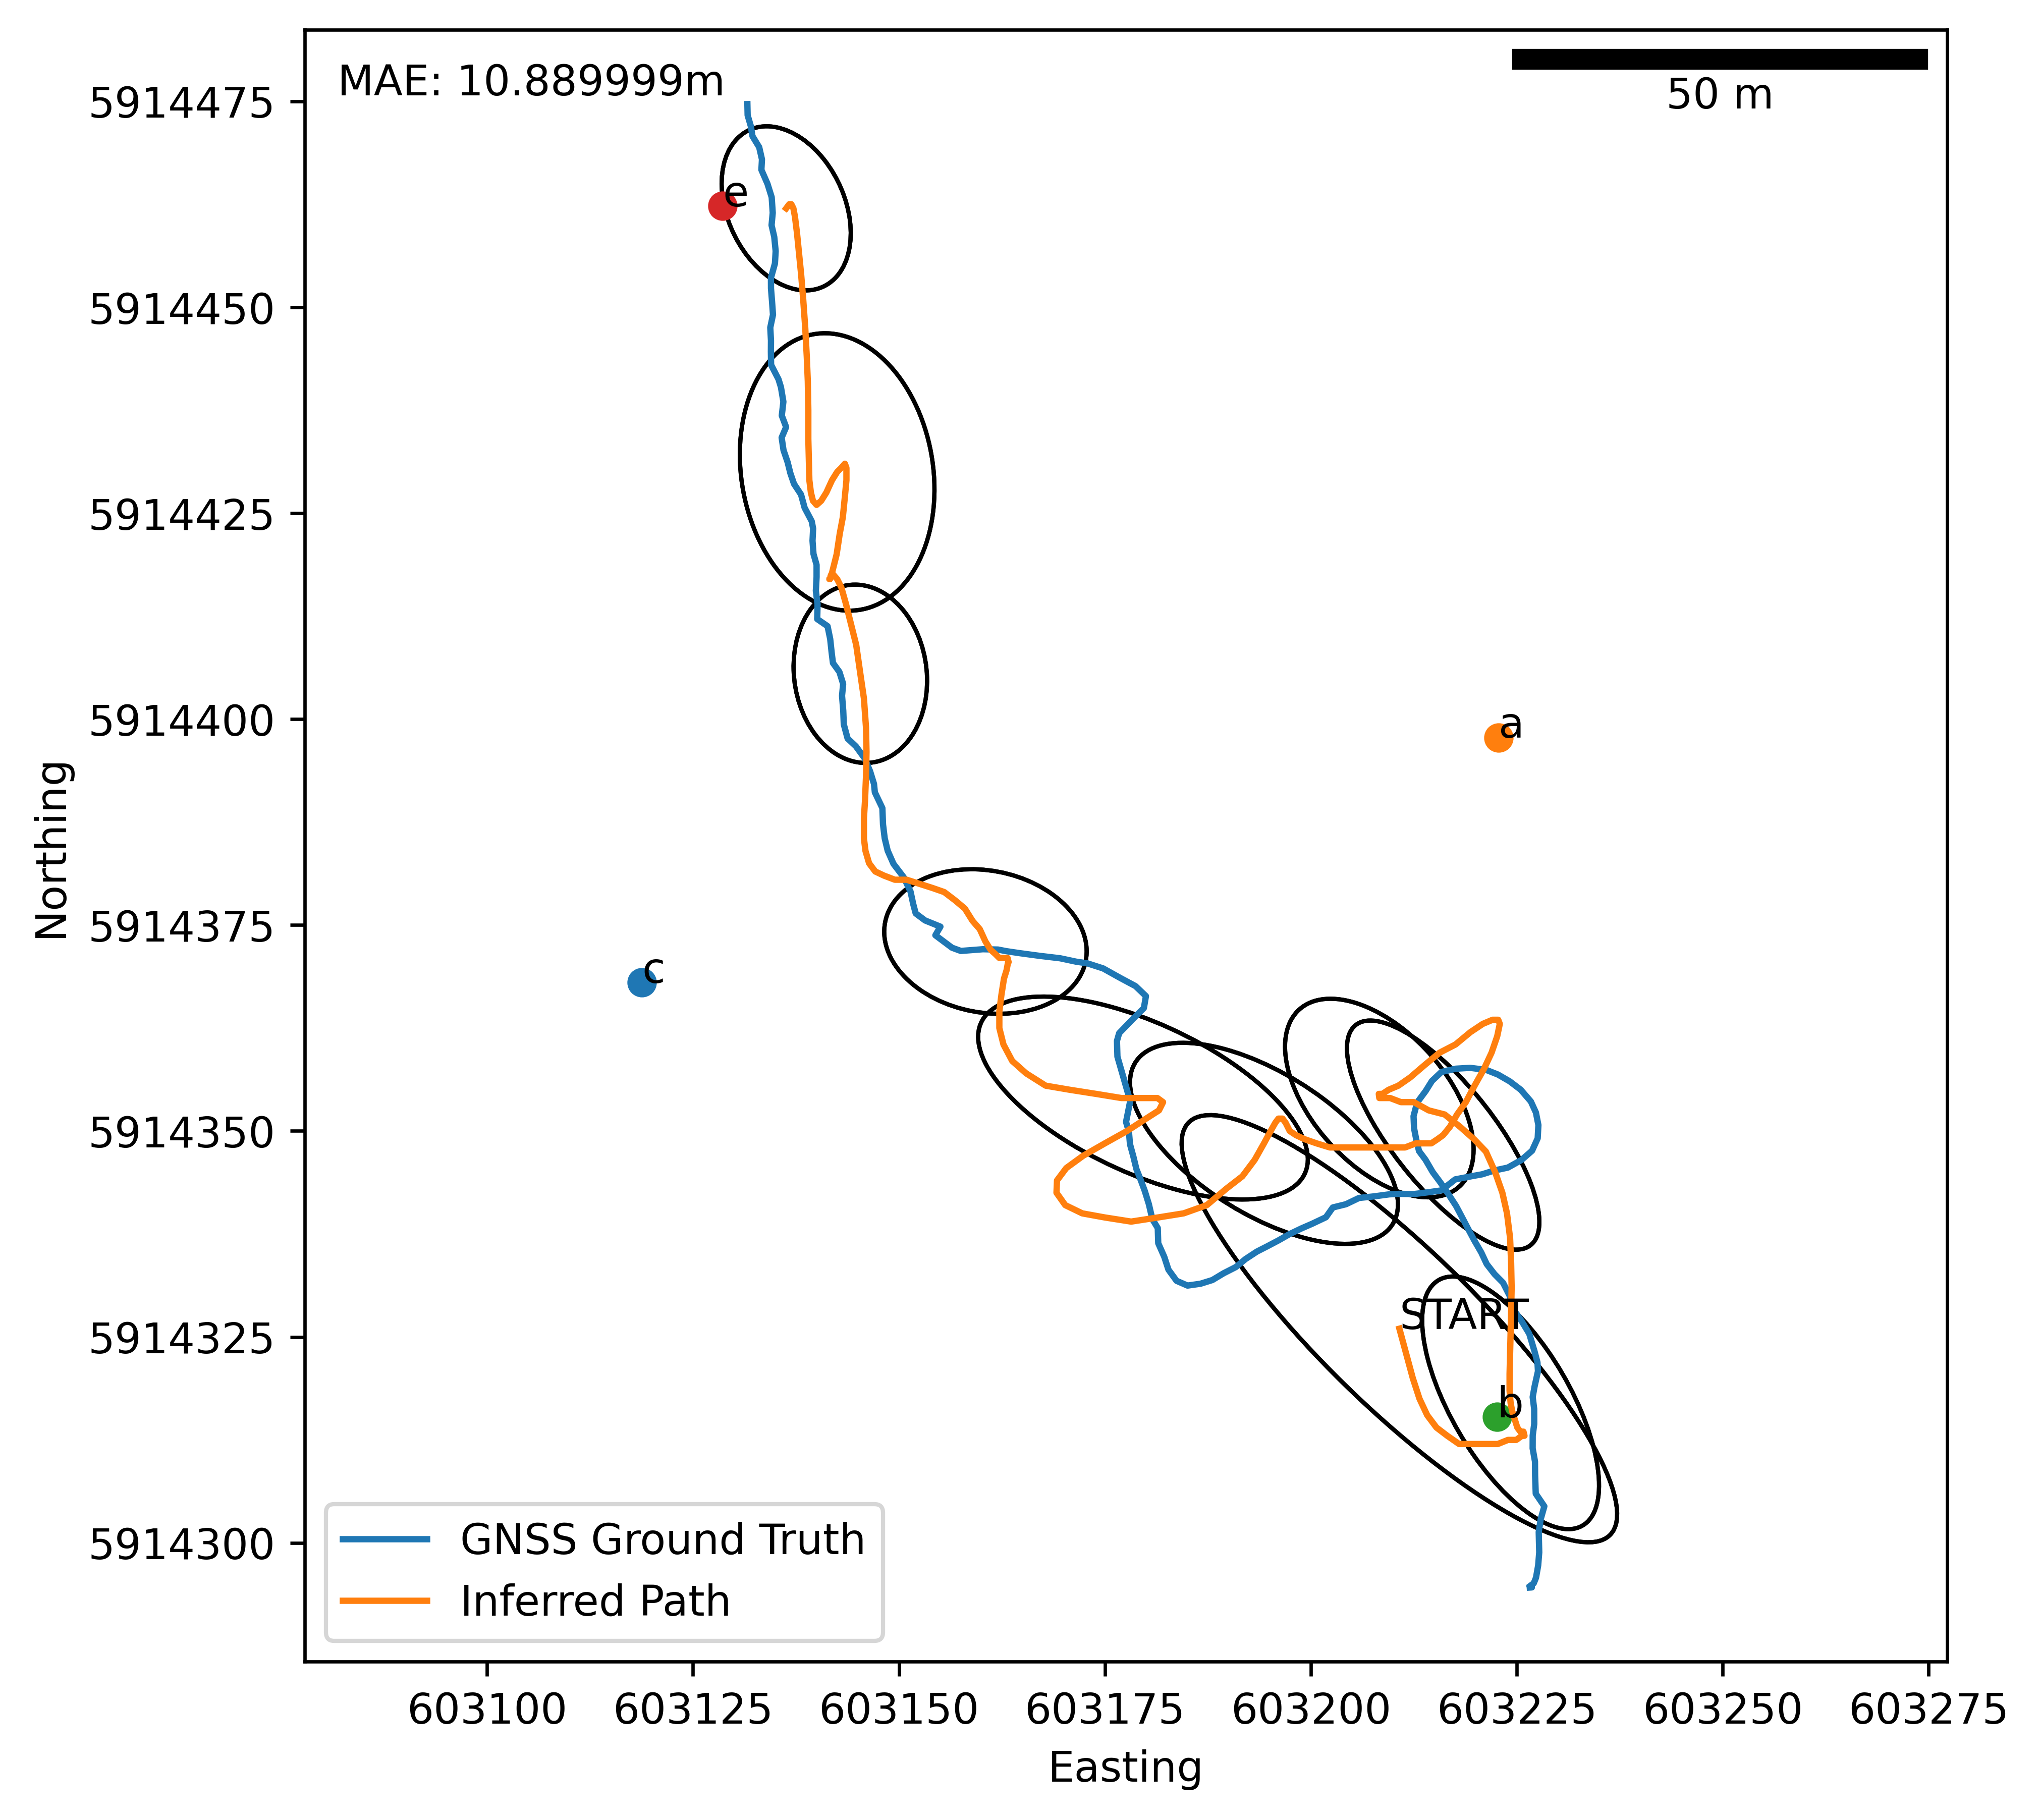

In [340]:
fig, ax1 = plt.subplots(figsize=(7, 7), dpi = 600)

path.plot(startTime = startingTime, endTime = endingTime, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath, n_std = 2)

#plt.title("Path Inferred from Vectors (Peak RSSI)")
plt.savefig("path2.png")

# Using rejection sampling

In [1065]:
obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)

# For each burst
for b in range(len(burst)):
    # Infer an angle
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    predictions = rejectionSampling.inferFromBurst(burst[b],filter=True,filterMean = 5, filterStd = 0.5)
    for prediction in predictions: 
        if not (np.isnan(prediction[1])):
            # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
            obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction[1]), np.cos(prediction[1])])
            # Add time of observation
            obstimes.append(time[b])

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


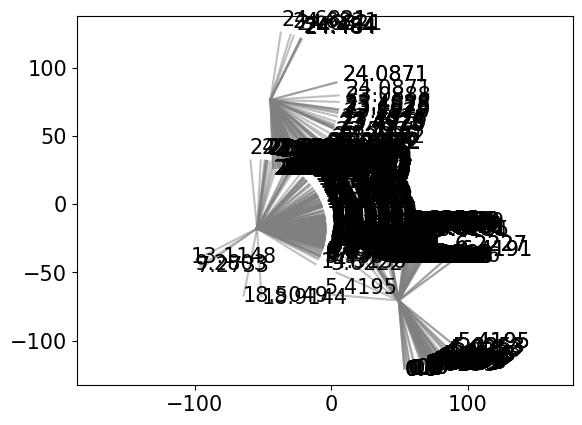

In [1066]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*55, observation[1]+observation[3]*55, time)

In [1067]:
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * margin, jitter = 0.1)
path.run(200,learning_rate=1, just_optimise_means = False)

Optimising mean...
iteration    0: 2447295.5
iteration   50:  380048.5
iteration  100:  180317.2
iteration  150:  157019.0
Optimising mean and covariance...
iteration    0:  156613.2
iteration   50:  122669.7
iteration  100:  123248.5
iteration  150:  121770.3


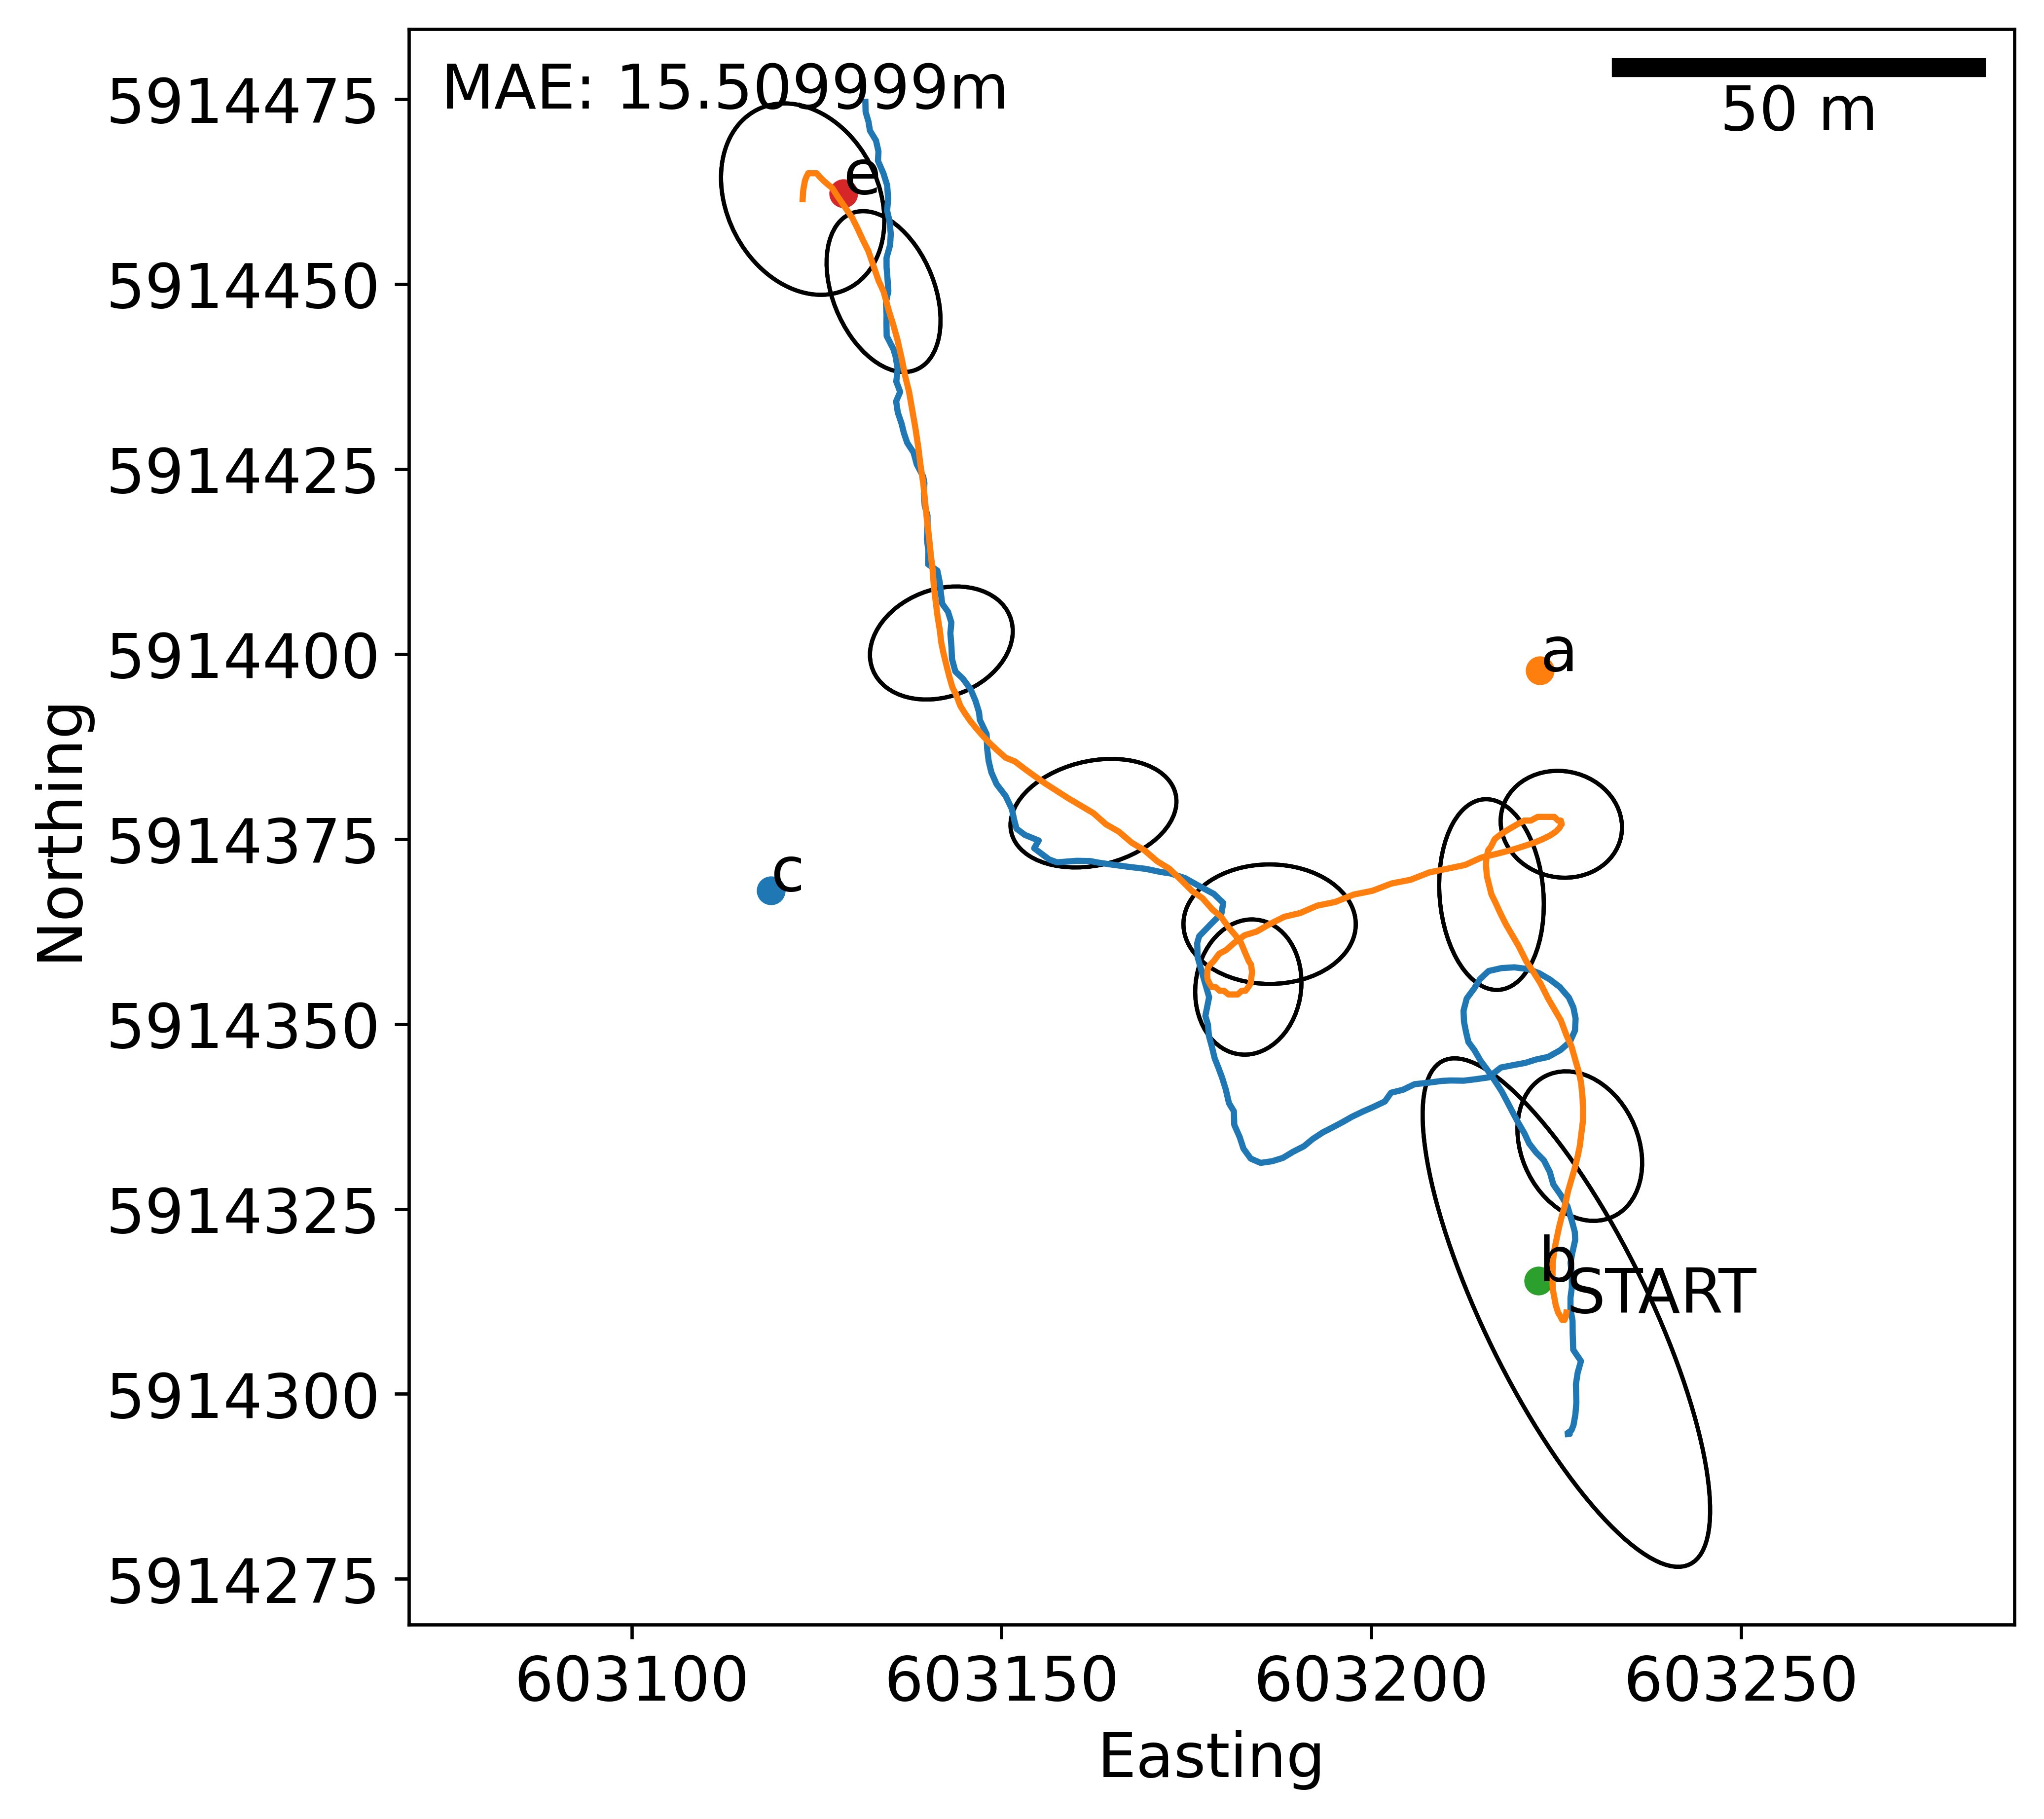

In [1071]:
fig, ax1 = plt.subplots(figsize=(7, 7), dpi = 600)

path.plot(startTime = startingTime-0.5, endTime = endingTime, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)

#plt.title("Path Inferred from Vectors (Rejection Sampling)")
ax1.legend_ = None
plt.savefig("path2.png")

# Using probability distribution

In [331]:
obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)
anglesPattern = AnglesUsePatternMeans(noisevar=6**2)

for b in range(len(burst)):
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    logps,_,_,_ = anglesPattern.infer(burst[b]['rssis'],burst[b]['angles'])
    ps = normalise_logs_to_ps(logps)
    prediction = np.argmax(ps)
    if not (np.isnan(prediction)):
        obstimes.append(time[b])
        obs.append(burst[b])
        
# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale

Standardising angles and times (shifting by 38.00 degrees)


In [333]:
# NOISE SCALE, INDUCING POINTS TODO : standardize order
path = Path_ProbabilityDensitiesToBee(np.array(obstimes),obs,k,noise,nInd, margin = np.max(obstimes) * margin, jitter = 1)
path.run(600,learning_rate=1, just_optimise_means = False)

Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   80331.9
iteration   50:   58272.2
iteration  100:   56749.6
iteration  150:   56697.6
iteration  200:   56722.8
iteration  250:   56707.1
iteration  300:   56675.0
iteration  350:   56678.2
iteration  400:   56731.5
iteration  450:   56695.6
iteration  500:   56676.4
iteration  550:   56724.7
Optimising mean and covariance...
iteration    0:   50969.4
iteration   50:   44183.9
iteration  100:   38789.2
iteration  150:   35747.5
iteration  200:   35196.0
iteration  250:   34731.2
iteration  300:   34390.2
iteration  350:   34594.6
iteration  400:   34684.7
iteration  450:   34012.6
iteration  500:   34130.9
iteration  550:   33816.7


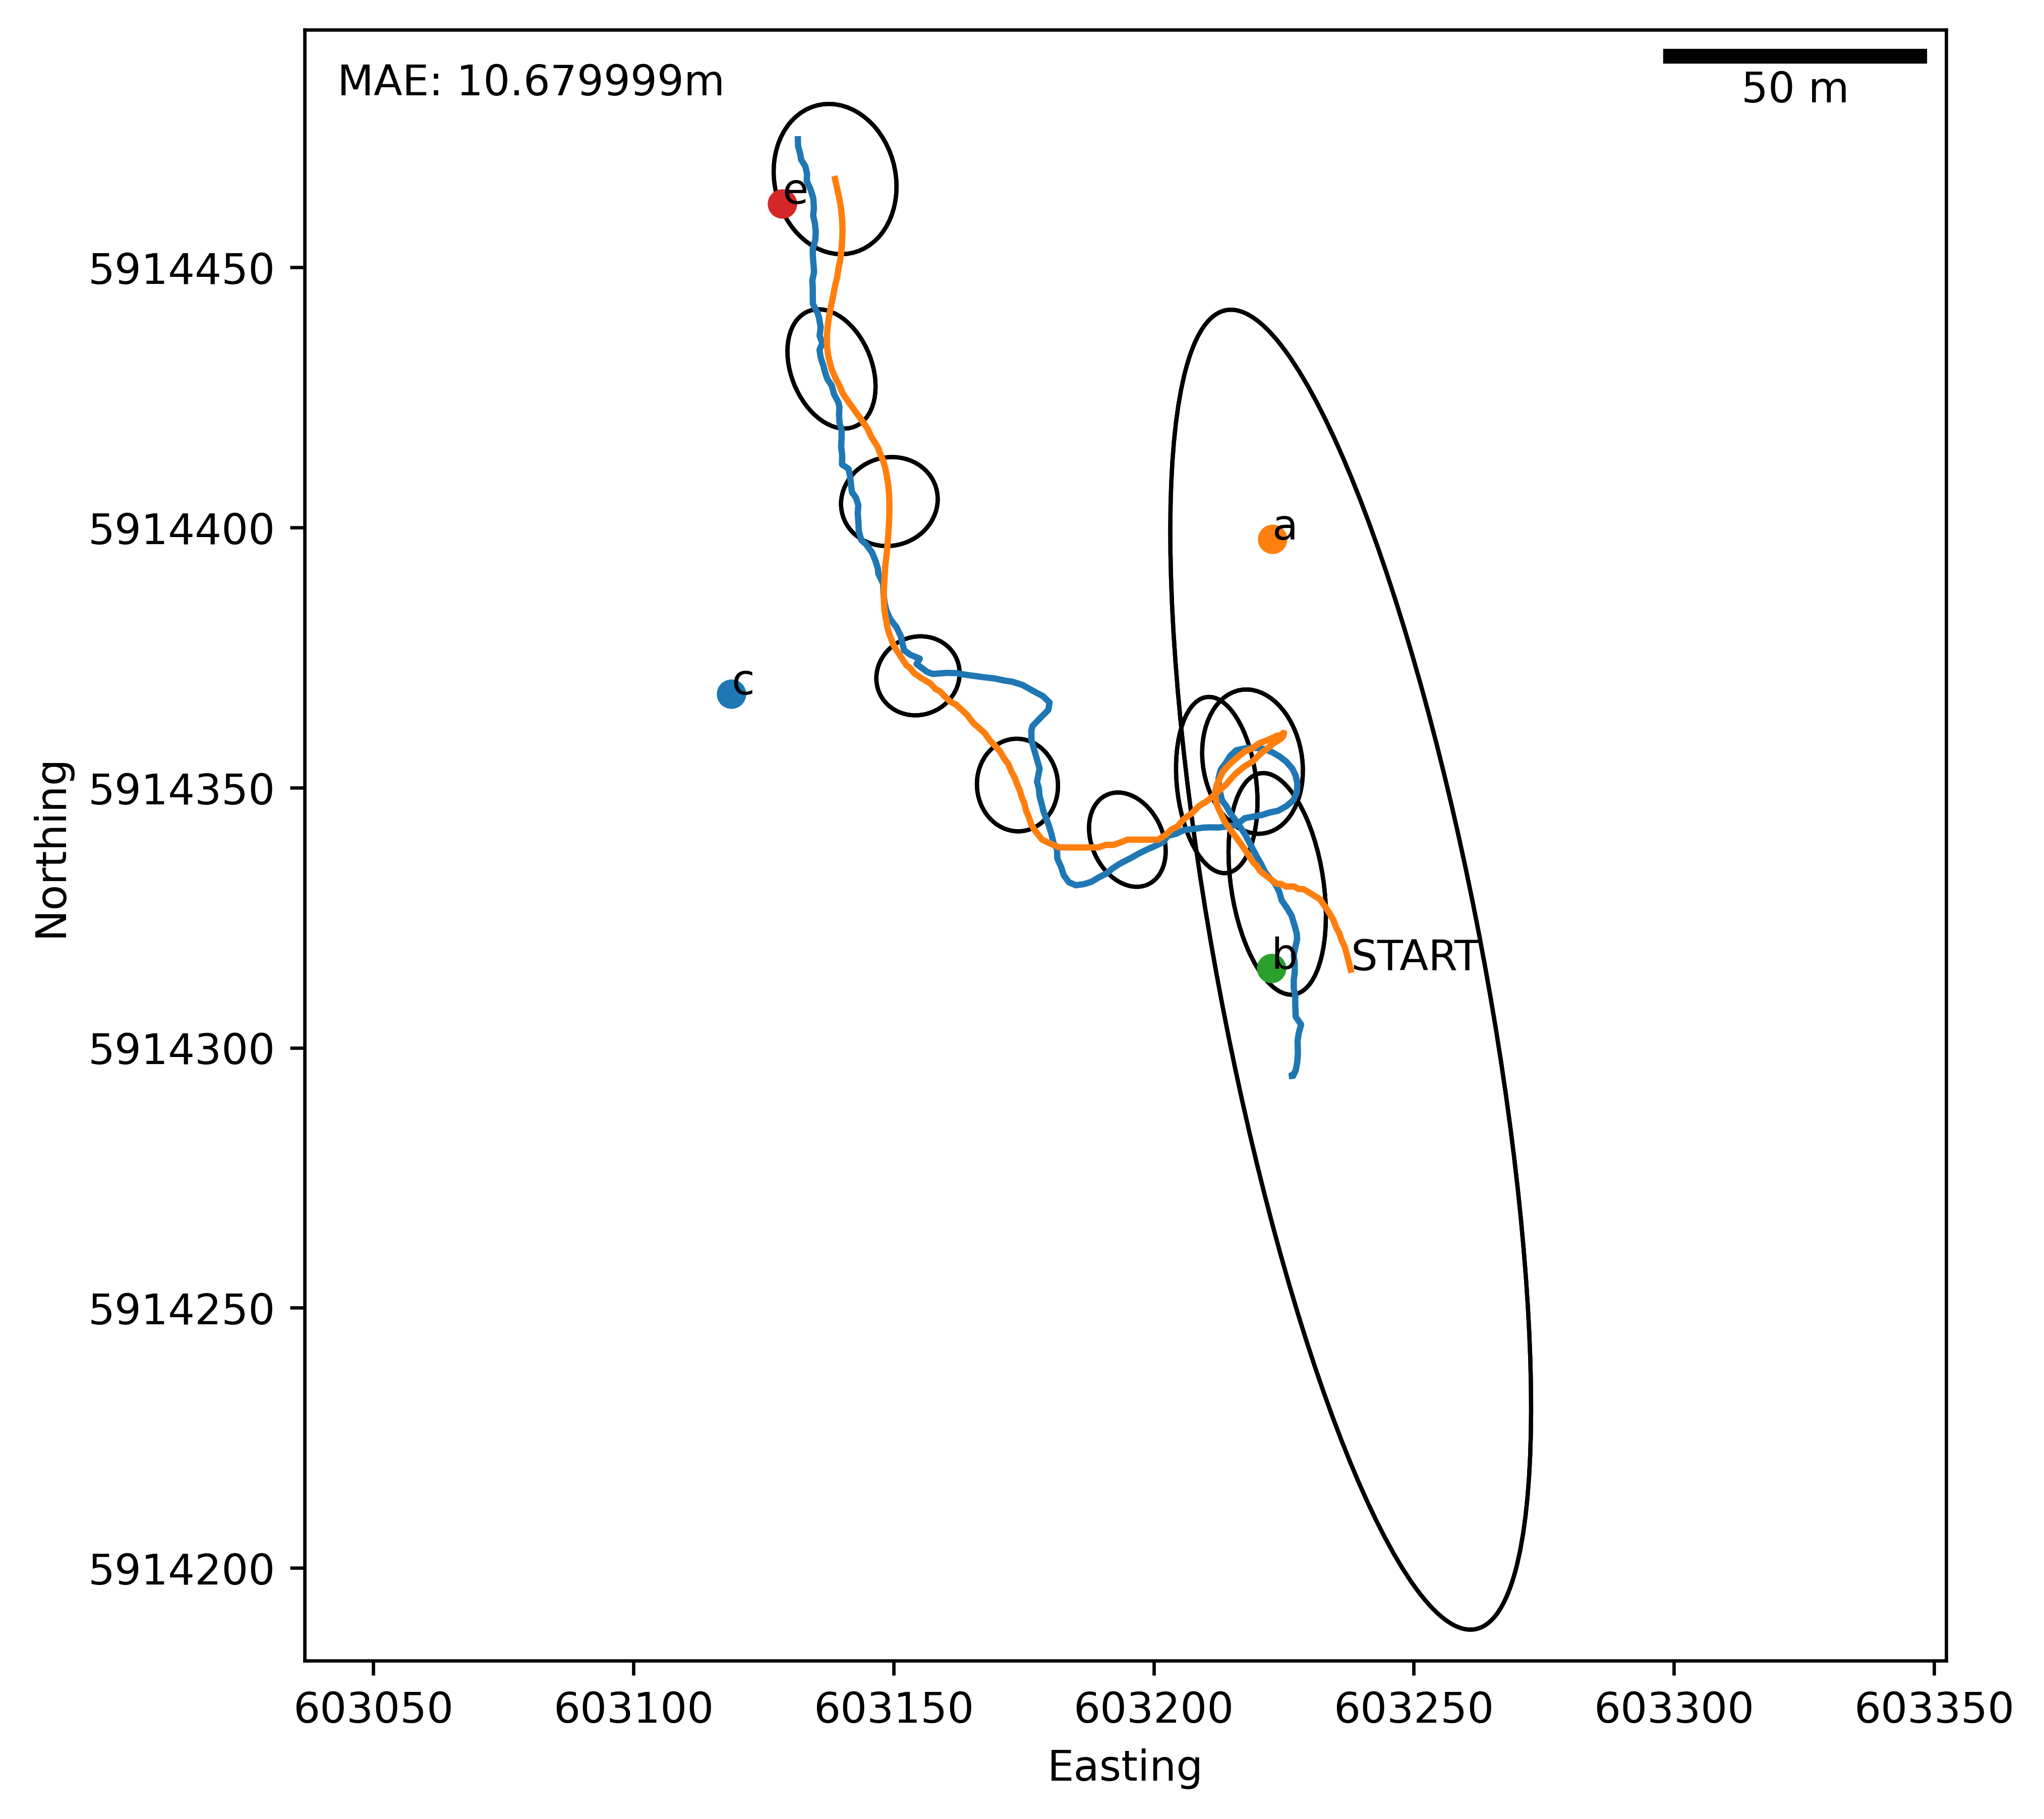

In [334]:
fig, ax1 = plt.subplots(figsize=(7, 7), dpi = 600)

path.plot(startTime = startingTime, endTime = endingTime, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval =10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath, n_std = 3)
#plt.title("Path Inferred from Probability Distributions")
ax1.legend_ = None
plt.savefig("path3.png")

# Full Test

In [366]:
peakResults = []
rejectionResults = []
fullProbResults = []

Standardising angles and times (shifting by 0.00 degrees)


/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0: 2405458.8
iteration   50: 1847650.1
iteration  100: 1827449.8
iteration  150: 1826869.1
Optimising mean and covariance...
iteration    0: 1824733.9
iteration   50: 1798296.8
iteration  100: 1795834.0
iteration  150: 1798374.9


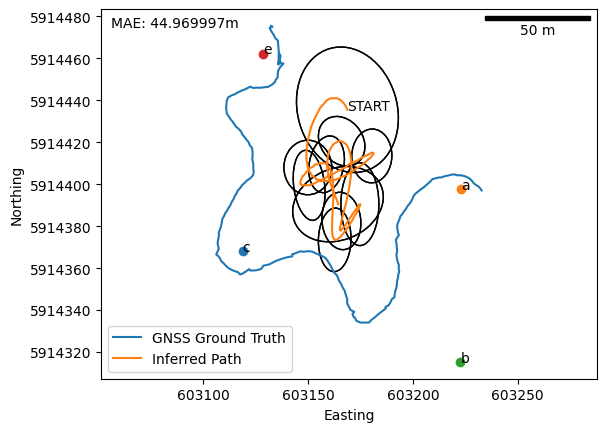

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


Optimising mean...
iteration    0:  617740.6
iteration   50:  247895.8
iteration  100:  206320.4
iteration  150:  191111.1
Optimising mean and covariance...
iteration    0:  165822.4
iteration   50:  123252.6
iteration  100:  116611.8
iteration  150:  115082.4


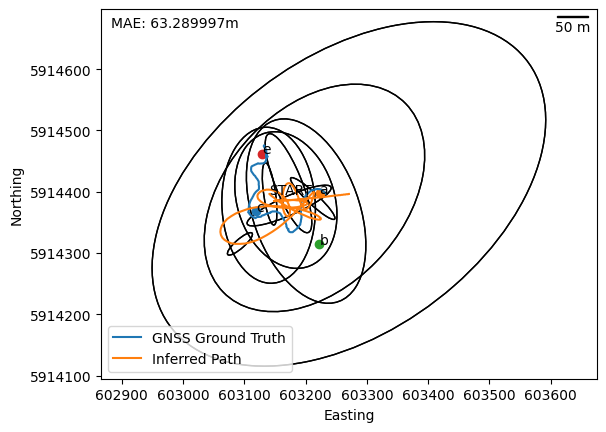

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:   74487.6
iteration   50:   57025.8
iteration  100:   56255.4
iteration  150:   56183.4
Optimising mean and covariance...
iteration    0:   36489.6
iteration   50:   28282.2
iteration  100:   26498.3
iteration  150:   24892.1


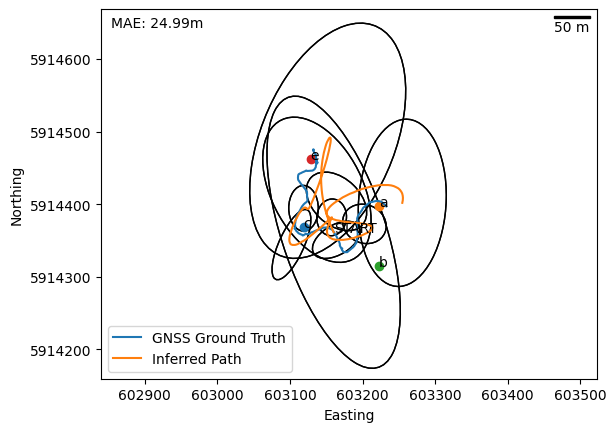

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0: 1759144.4
iteration   50:  792485.8
iteration  100:  697813.6
iteration  150:  690218.7
Optimising mean and covariance...
iteration    0:  678036.7
iteration   50:  648816.1
iteration  100:  645610.6
iteration  150:  646451.5


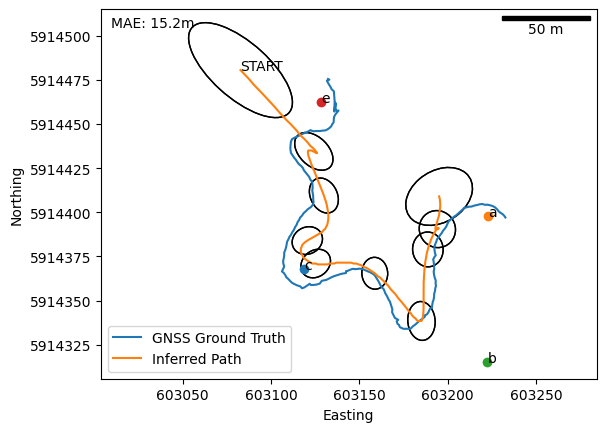

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


Optimising mean...
iteration    0: 1783360.8
iteration   50:  314404.8
iteration  100:  220623.5
iteration  150:  210340.8
Optimising mean and covariance...
iteration    0:  199394.5
iteration   50:  172099.4
iteration  100:  168257.5
iteration  150:  167016.6


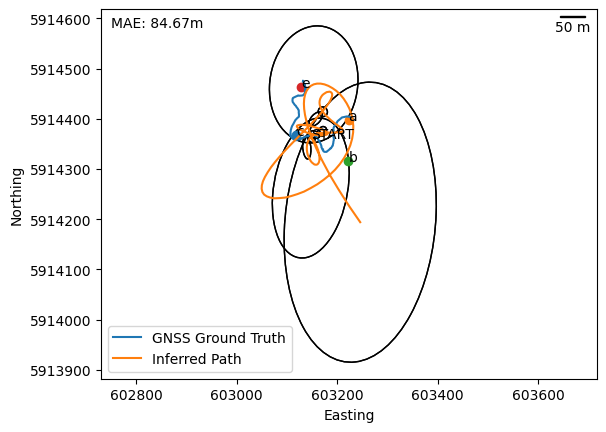

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  121628.2
iteration   50:   94663.8
iteration  100:   84821.2
iteration  150:   84535.5
Optimising mean and covariance...
iteration    0:   63032.3
iteration   50:   52865.3
iteration  100:   46562.5
iteration  150:   43937.9


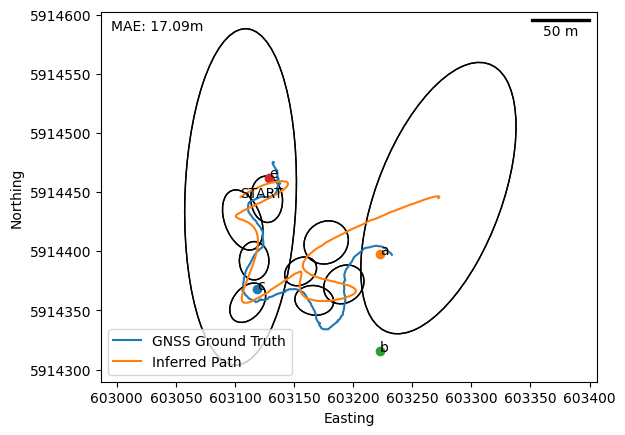

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0: 1524560.6
iteration   50:  340466.1
iteration  100:  236113.0
iteration  150:  231949.4
Optimising mean and covariance...
iteration    0:  218260.4
iteration   50:  190469.0
iteration  100:  189029.5
iteration  150:  189646.4


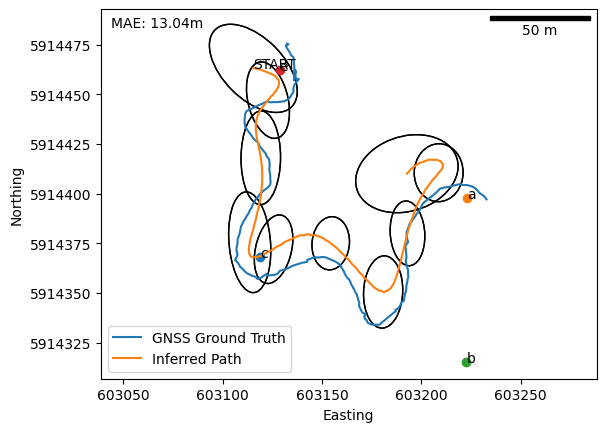

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


Optimising mean...
iteration    0: 4268597.0
iteration   50:  635466.1
iteration  100:  272844.5
iteration  150:  238196.5
Optimising mean and covariance...
iteration    0:  233271.7
iteration   50:  155597.2
iteration  100:  140692.6
iteration  150:  139390.0


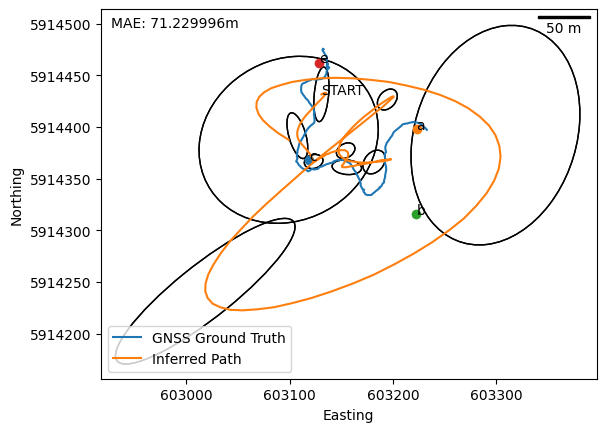

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  224681.7
iteration   50:  171577.6
iteration  100:  161867.3
iteration  150:  161718.5
Optimising mean and covariance...
iteration    0:  141539.9
iteration   50:  108216.9
iteration  100:   97717.0
iteration  150:   96946.8


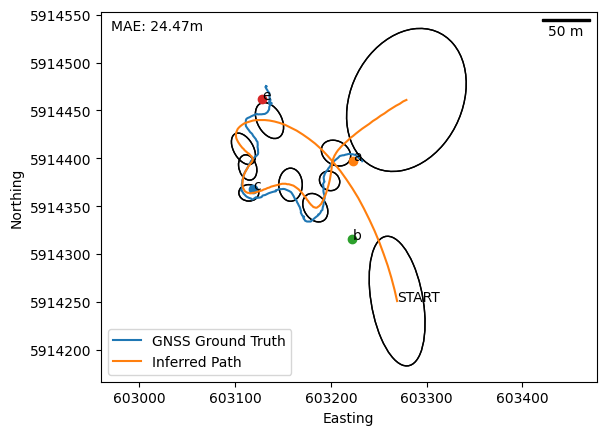

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0: 1496929.4
iteration   50:  306361.9
iteration  100:  204406.1
iteration  150:  199887.6
Optimising mean and covariance...
iteration    0:  186926.8
iteration   50:  158013.5
iteration  100:  155316.2
iteration  150:  154775.0


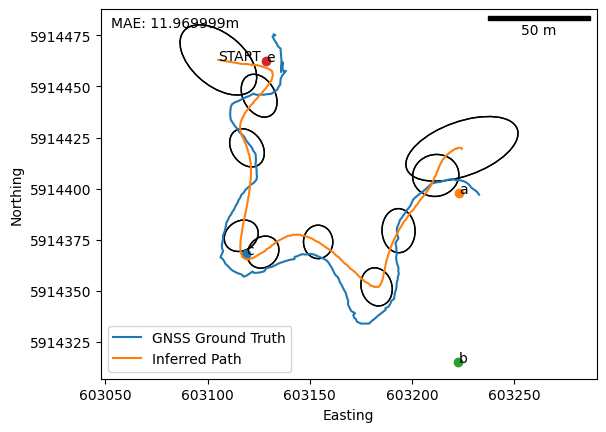

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


Optimising mean...
iteration    0: 4336735.5
iteration   50:  700375.8
iteration  100:  267182.0
iteration  150:  229753.5
Optimising mean and covariance...
iteration    0:  225351.8
iteration   50:  159373.5
iteration  100:  148207.3
iteration  150:  149240.0


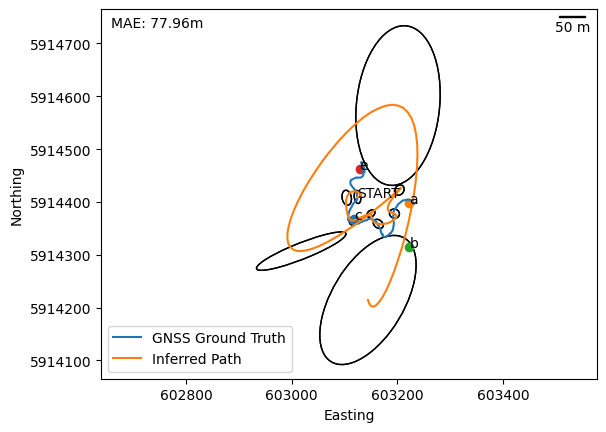

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  320563.0
iteration   50:  213635.8
iteration  100:  186379.5
iteration  150:  178735.5
Optimising mean and covariance...
iteration    0:  163821.0
iteration   50:  143320.9
iteration  100:  149836.5
iteration  150:  132683.5


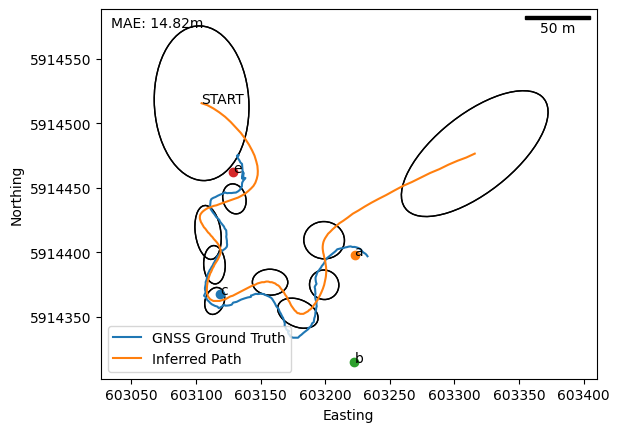

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0: 1568046.8
iteration   50:  316403.4
iteration  100:  196994.1
iteration  150:  191284.2
Optimising mean and covariance...
iteration    0:  178347.6
iteration   50:  149982.9
iteration  100:  148412.9
iteration  150:  149070.7


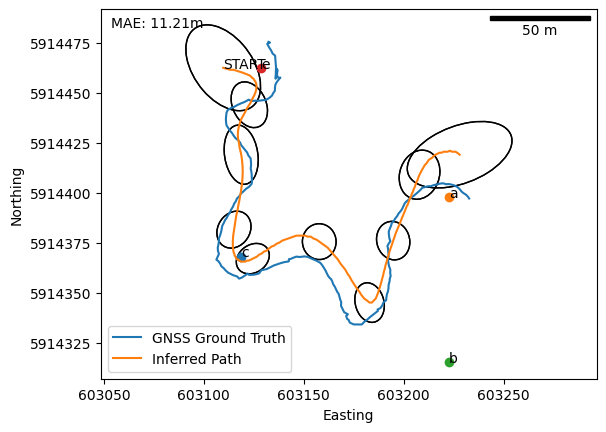

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


Optimising mean...
iteration    0: 4798091.5
iteration   50:  942501.2
iteration  100:  440096.9
iteration  150:  354650.7
Optimising mean and covariance...
iteration    0:  349976.7
iteration   50:  254798.7
iteration  100:  244520.3
iteration  150:  245811.3


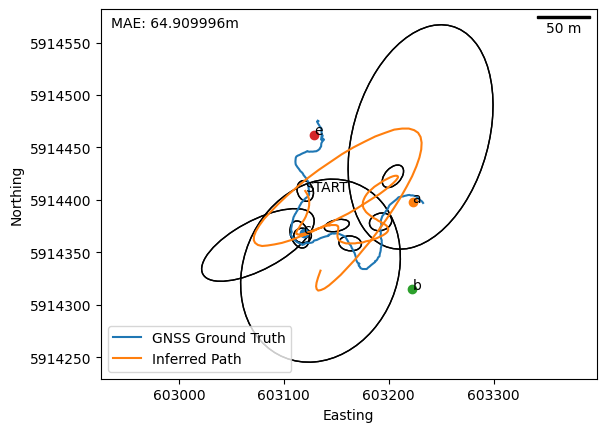

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  415515.2
iteration   50:  262773.6
iteration  100:  239747.5
iteration  150:  238444.5
Optimising mean and covariance...
iteration    0:  227216.8
iteration   50:  200881.3
iteration  100:  186226.2
iteration  150:  178375.0


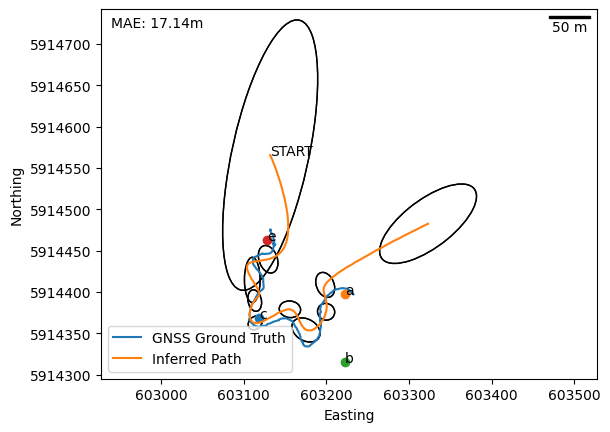

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0: 1523065.8
iteration   50:  301130.8
iteration  100:  189521.1
iteration  150:  184663.1
Optimising mean and covariance...
iteration    0:  172089.1
iteration   50:  143736.7
iteration  100:  141322.5
iteration  150:  140980.2


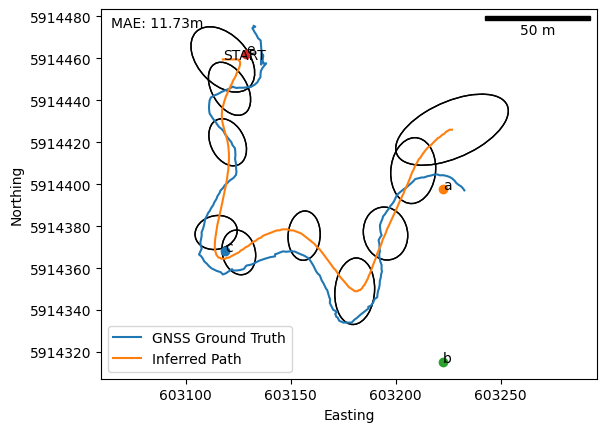

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


Optimising mean...
iteration    0: 4956747.0
iteration   50:  760936.8
iteration  100:  320170.1
iteration  150:  275989.2
Optimising mean and covariance...
iteration    0:  273780.6
iteration   50:  199992.8
iteration  100:  191580.4
iteration  150:  190395.8


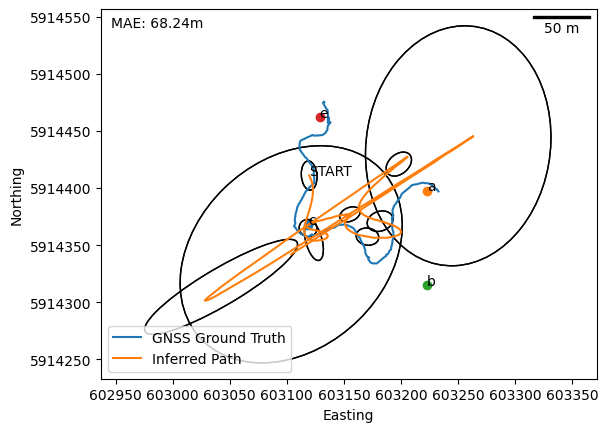

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  509089.8
iteration   50:  311624.2
iteration  100:  294375.4
iteration  150:  270153.2
Optimising mean and covariance...
iteration    0:  256589.3
iteration   50:  230110.5
iteration  100:  223136.3
iteration  150:  209847.3


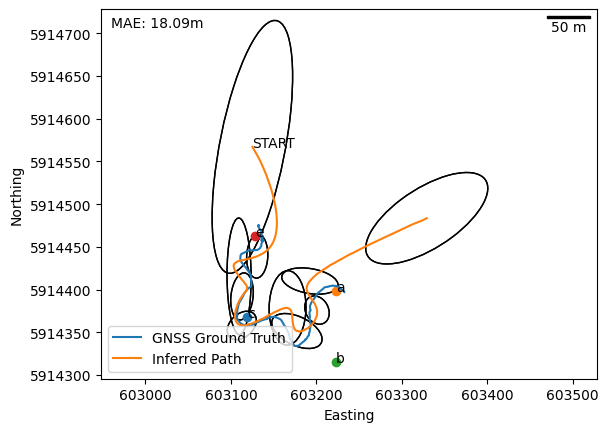

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0: 1518434.9
iteration   50:  312673.2
iteration  100:  202949.3
iteration  150:  198032.6
Optimising mean and covariance...
iteration    0:  184547.9
iteration   50:  155411.5
iteration  100:  152878.3
iteration  150:  152408.8


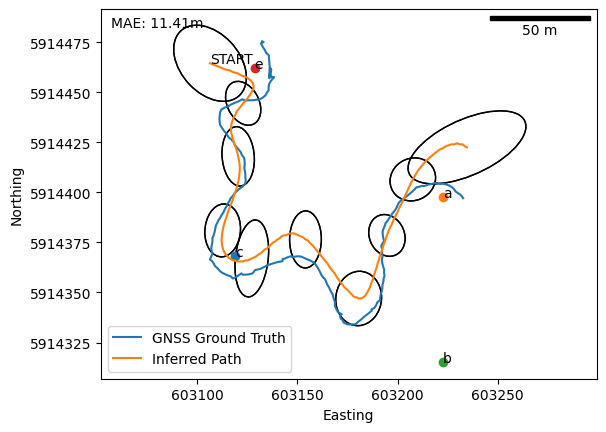

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


Optimising mean...
iteration    0: 5518438.5
iteration   50:  598877.2
iteration  100:  237357.8
iteration  150:  212916.9
Optimising mean and covariance...
iteration    0:  233466.2
iteration   50:  160544.8
iteration  100:  165633.6
iteration  150:  157349.5


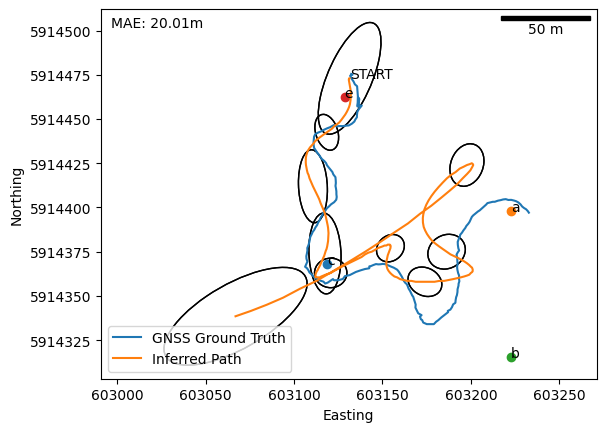

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0:  898692.6
iteration   50:  534708.2
iteration  100:  459751.8
iteration  150:  440881.8
Optimising mean and covariance...
iteration    0:  447613.1
iteration   50:  402209.3
iteration  100:  371399.3
iteration  150:  369459.9


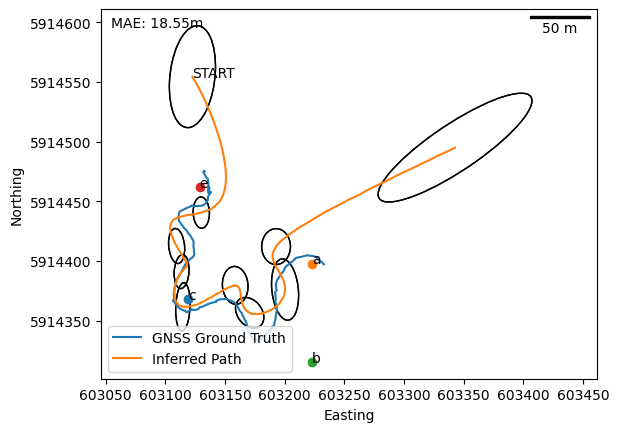

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Optimising mean...
iteration    0: 1531740.1
iteration   50:  310638.4
iteration  100:  197706.0
iteration  150:  192586.9
Optimising mean and covariance...
iteration    0:  179417.2
iteration   50:  151058.8
iteration  100:  148934.6
iteration  150:  149534.1


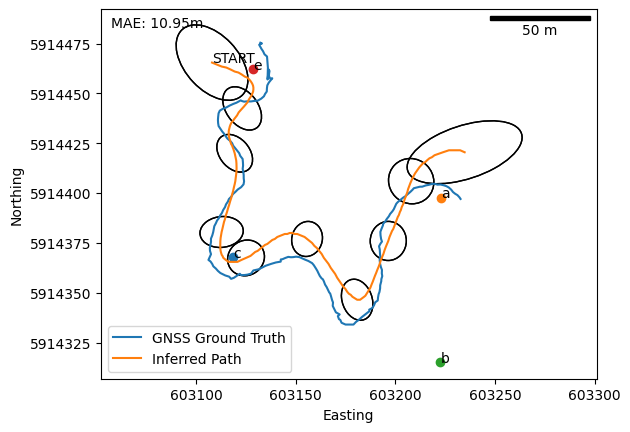

/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:215: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  predictions.append([t, (2 * np.pi - circmean(predangle)) % (2 * np.pi)])


Optimising mean...
iteration    0: 5613392.5
iteration   50:  586356.7
iteration  100:  234304.9
iteration  150:  201994.0
Optimising mean and covariance...
iteration    0:  216385.1
iteration   50:  142088.5
iteration  100:  137562.3
iteration  150:  137728.6


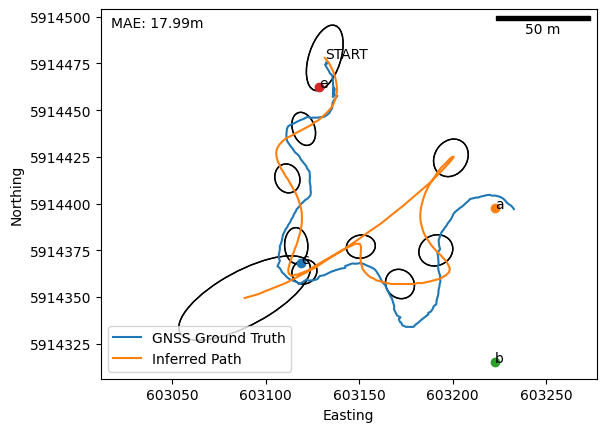

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0: 1459140.6
iteration   50:  887075.6
iteration  100:  700832.2
iteration  150:  674473.1
Optimising mean and covariance...
iteration    0:  675624.1
iteration   50:  572008.4
iteration  100:  563011.8
iteration  150:  554699.4


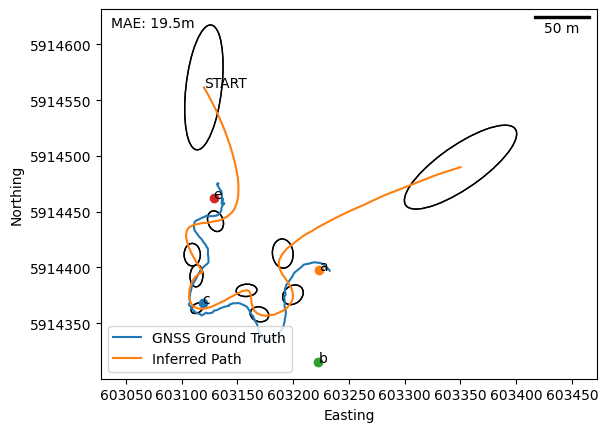

In [643]:
pathIndex = 2
kSamps = [3,5,10,15,20,25,50,100]
lr = 1
iterations = 200
k = EQIntegralKernel(2,5)
# Used these learning rates to ensure all tests converged to ELBO minima without becoming non PSD
# Path 1: 125 @ 2
# Path 2: 100 at 3
# Path 3: 200 at 1

# For evaluating the GPS path pointwise against the inferred path, we want to infer a path across the times that we've tracked with GPS
startingTime = paths[pathIndex][2]
endingTime = paths[pathIndex][3]


currentpeakResults = []
currentrejectionResults = []
currentfullProbResults = []

testdata = Signals(paths[pathIndex][0],['c','a','b','e'],filetype='log',angleOffset=0)
GPSfilepath = paths[pathIndex][1]
testdata.configureTransmitter('c',0,0,transmitterLat = 53.368359, transmitterLon = -1.450168)
testdata.configureTransmitter('a',-(167340+194210),0,transmitterLat = 53.368606, transmitterLon = -1.448596)
testdata.configureTransmitter('b',-(167340+194210+121110),0,transmitterLat = 53.367865, transmitterLon = -1.448626)
testdata.configureTransmitter('e',-167340,0,transmitterLat = 53.369204, transmitterLon = -1.449990)
# Normalise the transmitter locations around zero, in preparation for the observations
testdata.noramliseTransmitterLocs()

for nSamps in kSamps:
    # ---------- PEAK FINDING ----------
    
    obs = []
    obstimes = []
    
    # Get packet bursts from data
    burst, time = testdata.parseBursts(burstInterval=0)
    angles = AnglesUsePeaks(windowLength=3)
    
    # For each burst
    for b in range(len(burst)):
        # Infer an angle
        burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
        prediction = angles.infer(burst[b]['rssis'], burst[b]['angles'])
        # If a peak was found
        if not (np.isnan(prediction)):
            # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
            obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
            # Add time of observation
            obstimes.append(time[b])
    
    # Scale down times and standardise times such that they start at zero
    time_min = np.min(obstimes)
    for i in range(len(obstimes)):
        obstimes[i] = (obstimes[i] - time_min) / timeScale
    
    path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * margin, jitter = 0.1)
    path.run(iterations,learning_rate=lr, just_optimise_means = False)
    currentpeakResults.append(path)
    path.plot(startTime = startingTime, endTime = endingTime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 10, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = GPSfilepath)
    plt.show()
    
    # ---------- REJECTION SAMPLING ----------
    
    obs = []
    obstimes = []
    burst, time = testdata.parseBursts(burstInterval=0)
    
    # For each burst
    for b in range(len(burst)):
        # Infer an angle
        burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
        predictions = rejectionSampling.inferFromBurst(burst[b],filter=True,filterMean = 5, filterStd = 0.5)
        for prediction in predictions: 
            if not (np.isnan(prediction[1])):
                # Add observation in form [transmitter_x, transmitter_y, vector_x, vector_y]
                obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction[1]), np.cos(prediction[1])])
                # Add time of observation
                obstimes.append(time[b])
    
    # Scale down times and standardise times such that they start at zero
    time_min = np.min(obstimes)
    for i in range(len(obstimes)):
        obstimes[i] = (obstimes[i] - time_min) / timeScale
    
    path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,nInd,noise, margin = np.max(obstimes) * margin, jitter = 0.1)
    path.run(iterations,learning_rate=lr, just_optimise_means = False)
    currentrejectionResults.append(path)

    path.plot(startTime = startingTime, endTime = endingTime, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)
    plt.show()
    
    # ---------- FULL PROB DIST ----------
    obs = []
    obstimes = []
    burst, time = testdata.parseBursts(burstInterval=0)
    anglesPattern = AnglesUsePatternMeans(noisevar=3**2)
    
    for b in range(len(burst)):
        burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
        logps,_,_,_ = anglesPattern.infer(burst[b]['rssis'],burst[b]['angles'])
        ps = normalise_logs_to_ps(logps)
        prediction = np.argmax(ps)
        if not (np.isnan(prediction)):
            obstimes.append(time[b])
            obs.append(burst[b])
            
    # Scale down times and standardise times such that they start at zero
    time_min = np.min(obstimes)
    for i in range(len(obstimes)):
        obstimes[i] = (obstimes[i] - time_min) / timeScale
    
    path = Path_ProbabilityDensitiesToBee(np.array(obstimes),obs,k,noise,nInd, margin = np.max(obstimes) * margin, jitter = 0.1)
    path.run(iterations,learning_rate=lr, just_optimise_means = False)
    currentfullProbResults.append(path)
    path.plot(startTime = startingTime, endTime = endingTime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 10, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = GPSfilepath)
    plt.show()
    
    
peakResults.append(currentpeakResults)
rejectionResults.append(currentrejectionResults)
fullProbResults.append(currentfullProbResults)

27.803665


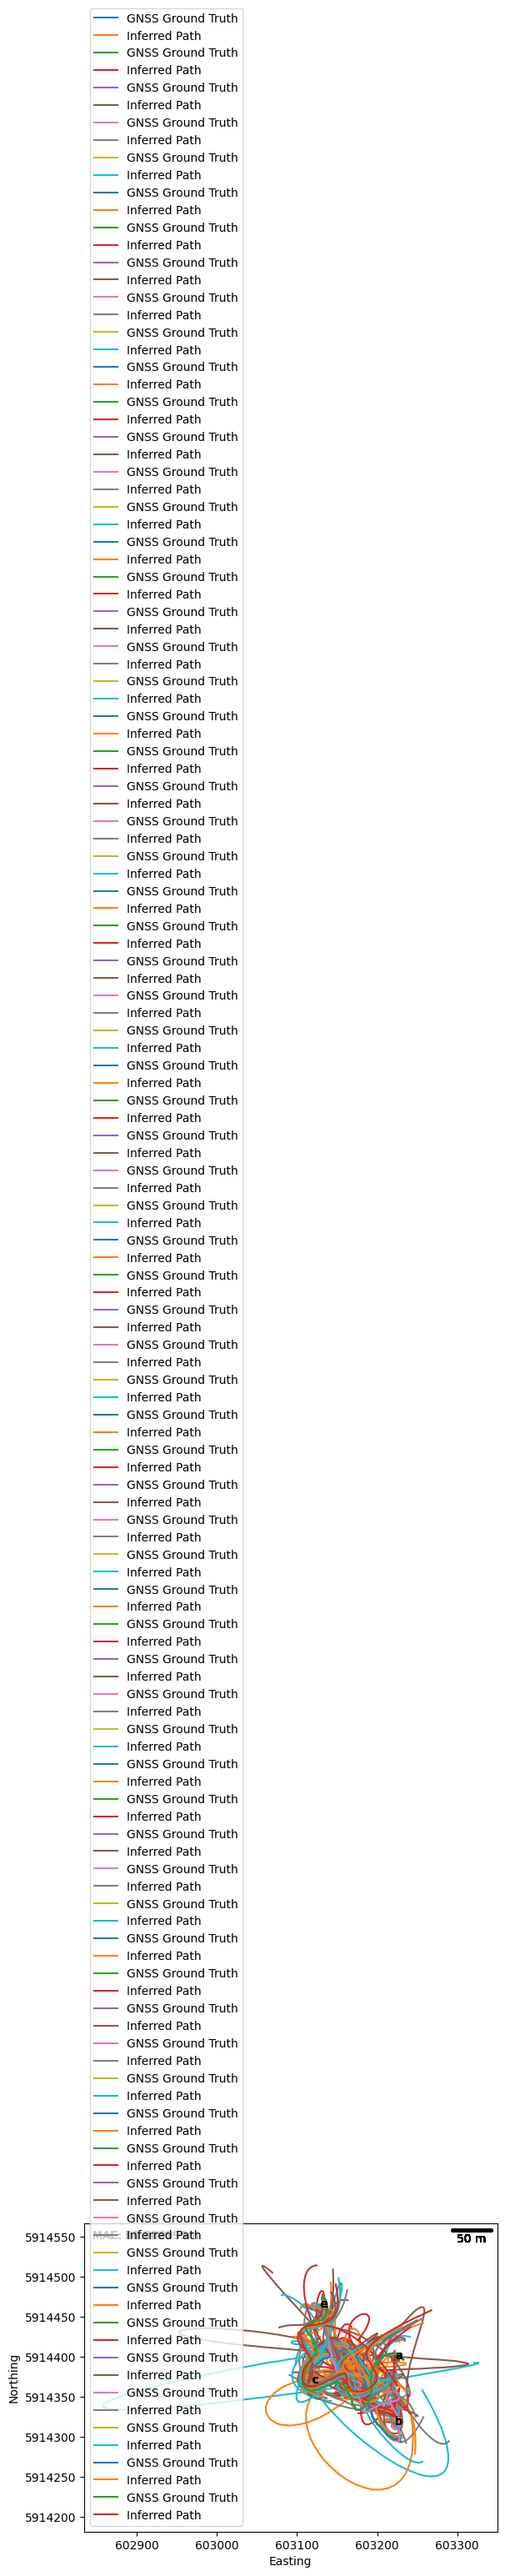

In [1008]:
# ---- Peak MAE Summing ----
path1 = [x.plot(startTime = x.starttime, endTime = x.endtime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[0][1]) for x in peakResults[0]]
path2 = [x.plot(startTime = x.starttime, endTime = x.endtime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[1][1]) for x in peakResults[1]]
path3 = [x.plot(startTime = x.starttime, endTime = x.endtime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[2][1]) for x in peakResults[2]]
print(path1[1])
peakMAE = np.sum([path1,path2,path3], axis=0)/3
peakSTD = np.std([path1,path2,path3], axis=0)

# ---- Rejection Sampling MAE Summing ----
path1 = [x.plot(startTime = x.starttime, endTime = x.endtime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[0][1]) for x in rejectionResults[0]]
path2 = [x.plot(startTime = x.starttime, endTime = x.endtime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[1][1]) for x in rejectionResults[1]]
path3 = [x.plot(startTime = x.starttime, endTime = x.endtime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[2][1]) for x in rejectionResults[2]]

rejectionMAE = np.sum([path1,path2,path3], axis=0)/3
rejectionSTD = np.std([path1,path2,path3], axis=0)

# ---- Peak MAE Summing ----
path1 = [x.plot(startTime = x.starttime, endTime = x.endtime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[0][1]) for x in fullProbResults[0]]
path2 = [x.plot(startTime = x.starttime, endTime = x.endtime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[1][1]) for x in fullProbResults[1]]
path3 = [x.plot(startTime = x.starttime, endTime = x.endtime, 
      transmitters = testdata.transmitterLocations, 
      ellipseInterval = 0, timeMultiplier = timeScale,
      coordScaleFactor = testdata.coordNormalisationFactor,
      GPSFile = paths[2][1]) for x in fullProbResults[2]]

fullprobMAE = np.sum([path1,path2,path3], axis=0)/3
fullprobSTD = np.std([path1,path2,path3], axis=0)

In [1009]:


with open("rejectionSampPathResultsMAE", "wb") as fp:
    pickle.dump(rejectionMAE, fp)
with open("peakFindingPathResultsMAE", "wb") as fp:
    pickle.dump(peakMAE, fp)
with open("fullProbabilityPathResultsMAE", "wb") as fp:
    pickle.dump(fullprobMAE, fp)
with open("rejectionSampPathResultsSTD", "wb") as fp:
    pickle.dump(rejectionSTD, fp)
with open("peakFindingPathResultsSTD", "wb") as fp:
    pickle.dump(peakSTD, fp)
with open("fullProbabilityPathResultsSTD", "wb") as fp:
    pickle.dump(fullprobSTD, fp)

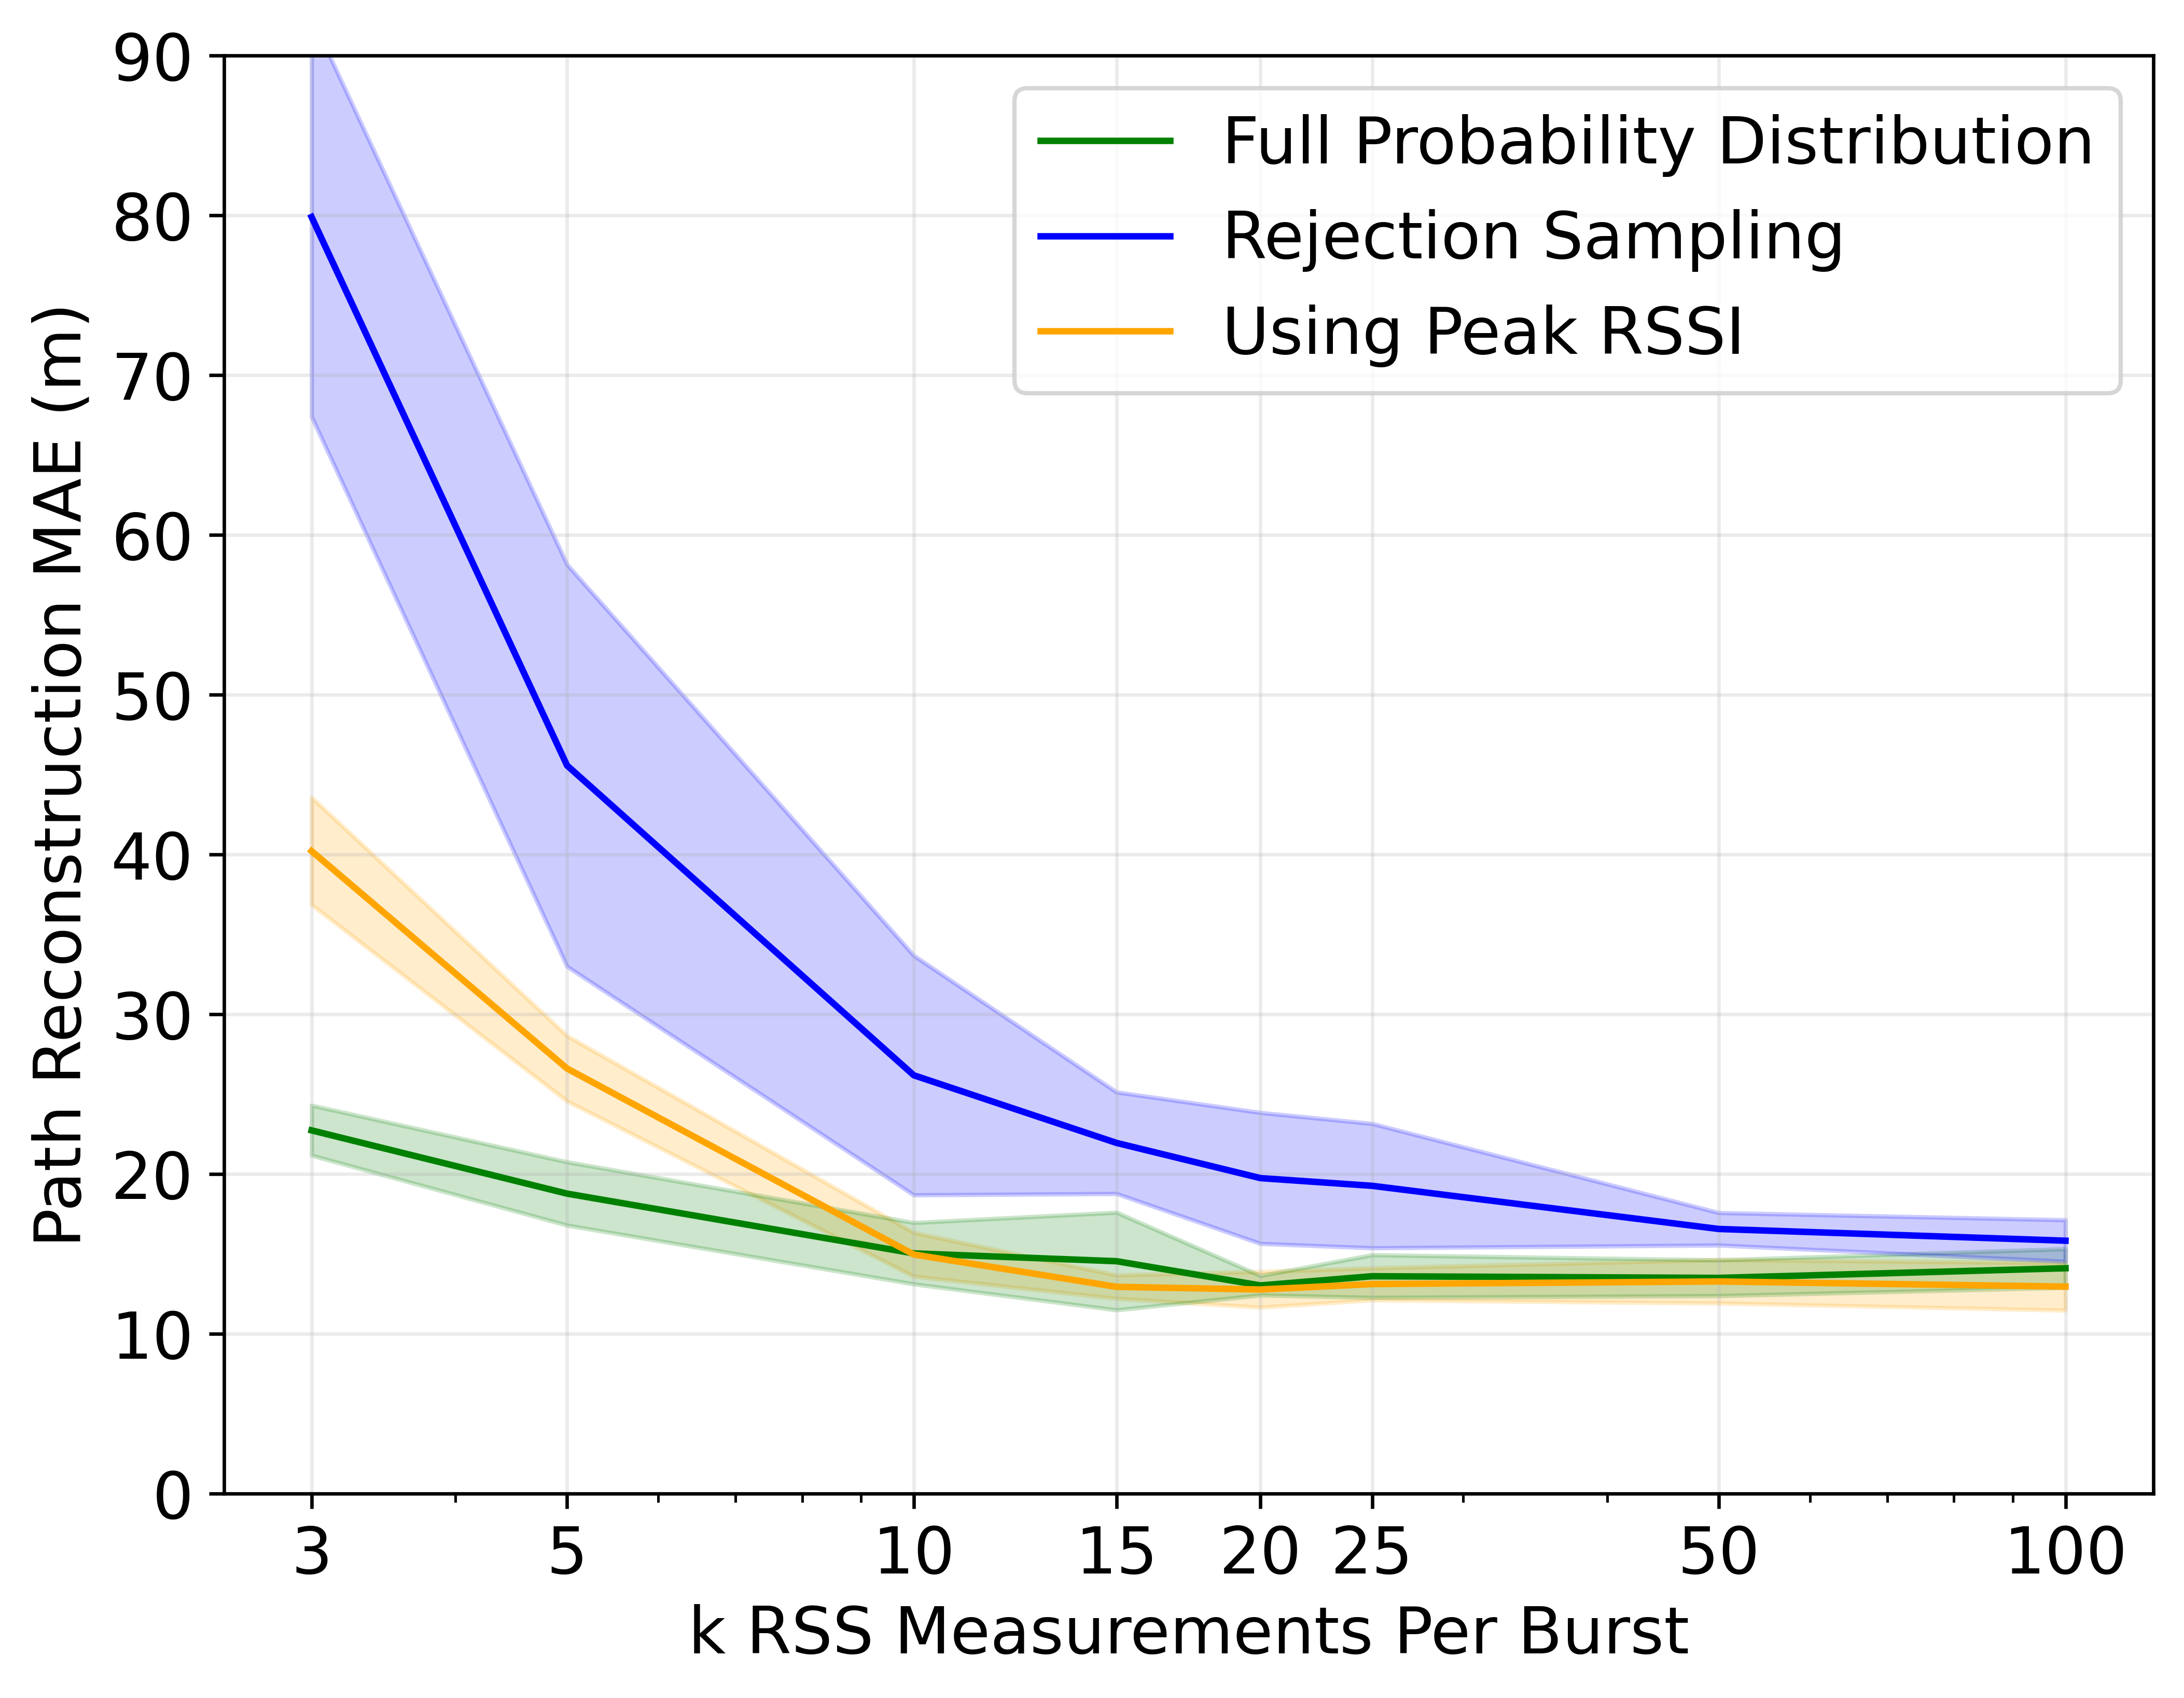

In [1033]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)
fig, ax1 = plt.subplots(figsize=(8,6),dpi=600)

plt.plot(kSamps, fullprobMAE, color="green", label="Full Probability Distribution")
plt.plot(kSamps, rejectionMAE, color="blue", label="Rejection Sampling")
plt.plot(kSamps, peakMAE,color="orange", label = "Using Peak RSSI")
plt.xscale("log")
plt.ylim(0,90)
plt.xticks(kSamps, [str(t) for t in kSamps])
plt.xlabel("k RSS Measurements Per Burst")
plt.ylabel("Path Reconstruction MAE (m)")
ax1.fill_between(
    kSamps,
    [m + s for m, s in zip(peakMAE, peakSTD)],
    [m - s for m, s in zip(peakMAE, peakSTD)],
    color="orange",
    alpha=0.2,
)
ax1.fill_between(
    kSamps,
    [m + s for m, s in zip(fullprobMAE, fullprobSTD)],
    [m - s for m, s in zip(fullprobMAE, fullprobSTD)],
    color="green",
    alpha=0.2,
)
ax1.fill_between(
    kSamps,
    [m + s for m, s in zip(rejectionMAE, rejectionSTD)],
    [m - s for m, s in zip(rejectionMAE, rejectionSTD)],
    color="blue",
    alpha=0.2,
)
plt.legend()
ax1.grid(alpha=0.25)
plt.savefig("4.png")
plt.show()

# Using vectors sampled from probability distribution (not assessed in paper)

In [546]:
obs = []
obstimes = []
burst, time = testdata.parseBursts(burstInterval=0)
anglesPattern = AnglesUsePatternMeans(noisevar=10**2)
    
for b in range(len(burst)):
    burst[b] = testdata.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
    logps,_,_,_ = anglesPattern.infer(burst[b]['rssis'],burst[b]['angles'])
    ps = normalise_logs_to_ps(logps)
    prediction = np.argmax(ps)
    if not (np.isnan(prediction)):
        if np.sum(np.log(ps)*ps) > -5.5:
            prediction = np.deg2rad(prediction)
            obs.append([burst[b]['transmitter_position'][0][1], burst[b]['transmitter_position'][0][0], np.sin(prediction), np.cos(prediction)])
            obstimes.append(time[b])

print("Filtered down to " + str(len(obs)) + " packets.")

# Scale down times and standardise times such that they start at zero
time_min = np.min(obstimes)
for i in range(len(obstimes)):
    obstimes[i] = (obstimes[i] - time_min) / timeScale


Standardising angles and times (shifting by 38.00 degrees)
Filtered down to 75 packets.


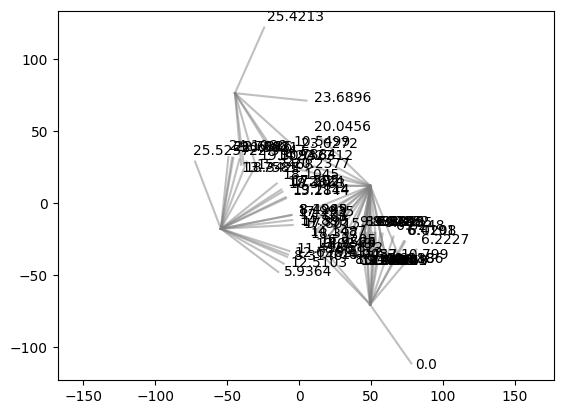

In [547]:
plt.axis('equal')
for (observation, time) in zip(obs, obstimes):
    plt.plot([observation[0], observation[0]+observation[2]*50],[observation[1],observation[1]+observation[3]*50],color='grey',alpha=0.5)
    plt.text(observation[0]+observation[2]*55, observation[1]+observation[3]*55, time)

In [548]:
path = Path_VectorsToBee(np.array(obstimes),np.array(obs),k,20,noise, margin = np.max(obstimes) * 0.05, jitter = 0.01)
path.run(200,learning_rate=1, just_optimise_means = False)

Optimising mean...
iteration    0:  344296.5
iteration   50:   84021.2
iteration  100:   65131.6
iteration  150:   64472.3
Optimising mean and covariance...
iteration    0:   48647.7
iteration   50:   40099.3
iteration  100:   36201.3
iteration  150:   35364.2


Text(0.5, 1.0, 'Path Inferred from Vectors (Peak RSSI)')

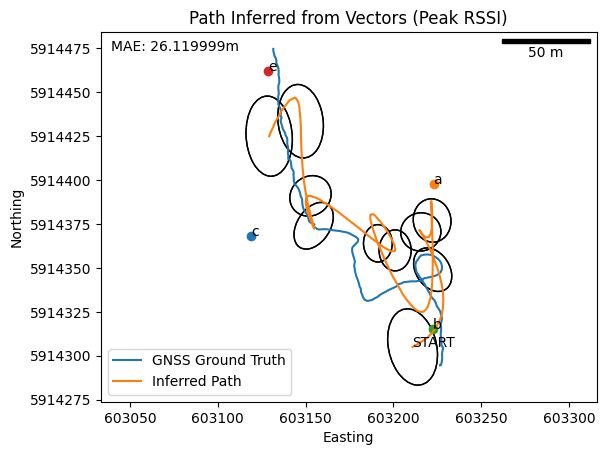

In [549]:
path.plot(startTime = startingTime+1, endTime = endingTime-2, 
          transmitters = testdata.transmitterLocations, 
          ellipseInterval = 10, timeMultiplier = timeScale,
          coordScaleFactor = testdata.coordNormalisationFactor,
          GPSFile = GPSfilepath)

plt.title("Path Inferred from Vectors (Peak RSSI)")